# Data Preparation



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure directory exists
os.makedirs('figures', exist_ok=True)
os.makedirs('input', exist_ok=True)

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42

CMAP_STYLE = "Blues"

## Load Augmented Dataset

In [3]:
# Load the dataset
df = pd.read_csv("input/DatosEntrenamiento_DistProbTransEspacial_balanced.csv")

# Separate data and labels
labels = df["POSICION"].values
unique_labels = np.unique(labels)
data = df.drop(columns=["POSICION"]).values

# Find the max value for normalization
data_min = data.min()
data_max = data.max()
print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Data range: [{data_min.min():.4f}, {data_max.max():.4f}]")
print(f"Labels: {unique_labels}")

Data shape: (300000, 64)
Data type: float64
Data range: [0.0000, 233.4754]
Labels: ['fetus_L' 'fetus_R' 'prone' 'supine' 'trunk_L' 'trunk_R']


## Training, Validation and Test Data
Separate datasets into (40/20/40)% 

Saves in `.npz` for TensorFlow and PYNQ-Z2 (Python)

In [4]:
TRAIN = 0.4 # 40%
VALIDATION = 0.2 # 20%
TEST = 0.4 # 40%

# Split indices with stratification for equal amount of sample labels in each dataset

# First split
idx_train, idx_temp = train_test_split(
    range(len(labels)), test_size=(VALIDATION+TEST),
    random_state=RANDOM_STATE, stratify=labels
)

# Second split
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST / (VALIDATION+TEST),
    random_state=RANDOM_STATE, stratify=labels[idx_temp]
)

# Samples in datasets
print(f"  Training:   {len(idx_train)} samples ({len(idx_train)/len(labels)*100:.0f}%)")
print(f"  Validation: {len(idx_val)} samples ({len(idx_val)/len(labels)*100:.0f}%)")
print(f"  Test:       {len(idx_test)} samples ({len(idx_test)/len(labels)*100:.0f}%)")

# Class distribution
print("\nClass distribution:")
for label in unique_labels:
    train_count = np.sum(labels[idx_train] == label)
    val_count = np.sum(labels[idx_val] == label)
    test_count = np.sum(labels[idx_test] == label)
    print(f"  {label}: Train={train_count}, Val={val_count}, Test={test_count}")

  Training:   119999 samples (40%)
  Validation: 60000 samples (20%)
  Test:       120001 samples (40%)

Class distribution:
  fetus_L: Train=20000, Val=10000, Test=20000
  fetus_R: Train=20000, Val=10000, Test=20000
  prone: Train=20000, Val=10000, Test=20000
  supine: Train=19999, Val=10000, Test=20001
  trunk_L: Train=20000, Val=10000, Test=20000
  trunk_R: Train=20000, Val=10000, Test=20000


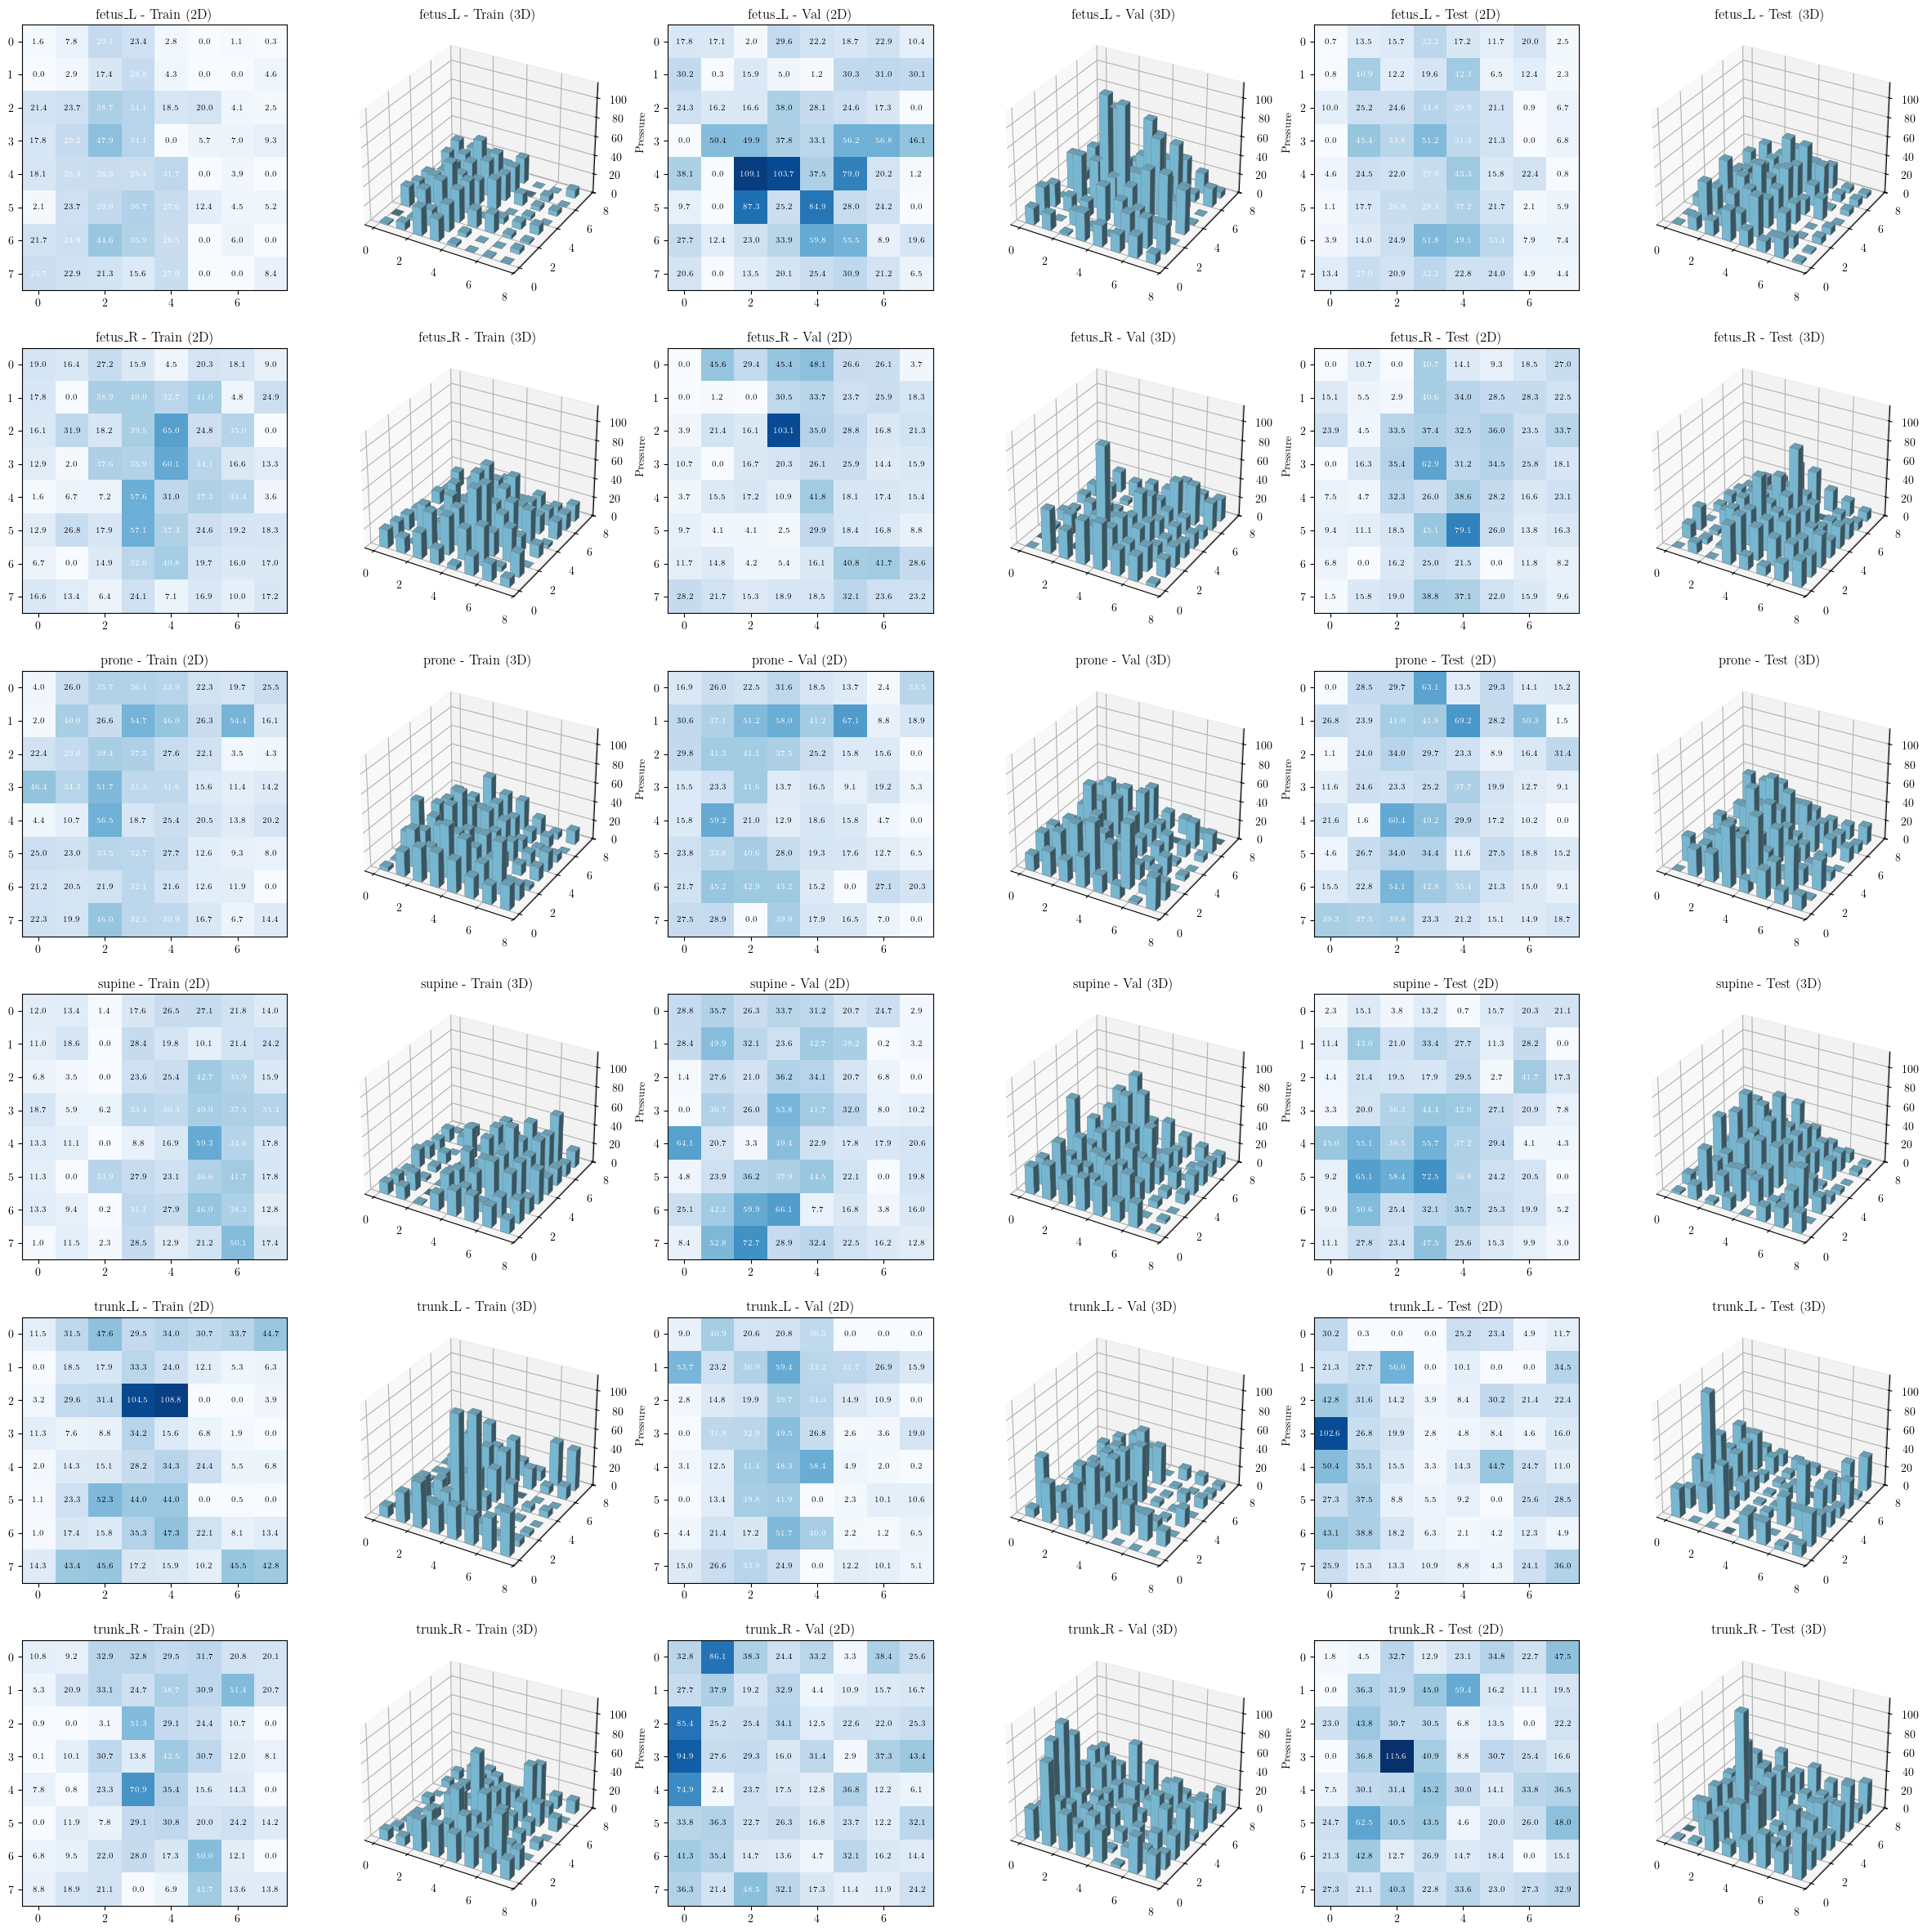

Saved: figures/split_comparison.pdf


In [5]:
splits = {
    'train': (idx_train, labels[idx_train]),
    'val': (idx_val, labels[idx_val]),
    'test': (idx_test, labels[idx_test])
}

# Collect all raw data samples to determine global max for consistent z-axis scaling
raw_samples = []
for label in unique_labels:
    for split_name, (idx_split, labels_split) in splits.items():
        idx_in_split = np.where(labels_split == label)[0][0]
        orig_idx = idx_split[idx_in_split]
        raw_samples.append(data[orig_idx].reshape(8, 8))

global_max = np.max(raw_samples)

# Compare splits: one sample per label from each split to verify class balance
# Layout: 6 rows (labels) × 6 columns (Train/Val/Test × 2D/3D)
fig2 = plt.figure(figsize=(24, 24))

X, Y = np.meshgrid(range(8), range(8))
x_pos = X.ravel()
y_pos = Y.ravel()
z_pos = np.zeros_like(x_pos)
dx = dy = 0.5 * np.ones_like(x_pos)

for i, label in enumerate(unique_labels):
    row = i
    
    train_idx_in_split = np.where(splits['train'][1] == label)[0][0]
    val_idx_in_split = np.where(splits['val'][1] == label)[0][0]
    test_idx_in_split = np.where(splits['test'][1] == label)[0][0]
    
    train_orig_idx = splits['train'][0][train_idx_in_split]
    val_orig_idx = splits['val'][0][val_idx_in_split]
    test_orig_idx = splits['test'][0][test_idx_in_split]
    
    train = data[train_orig_idx].reshape(8, 8)
    val = data[val_orig_idx].reshape(8, 8)
    test = data[test_orig_idx].reshape(8, 8)
    
    for raw_data, split_name, col_offset in [
        (train, 'Train', 0),
        (val, 'Val', 2),
        (test, 'Test', 4)
    ]:
        # 2D heatmap
        ax2d = fig2.add_subplot(6, 6, row * 6 + col_offset + 1)
        im2d = ax2d.imshow(raw_data, cmap=CMAP_STYLE, vmin=0, vmax=global_max)
        ax2d.set_title(f"{label} - {split_name} (2D)")
        for r in range(8):
            for c in range(8):
                val = raw_data[r, c]
                color = "white" if val > raw_data.max() / 2 else "black"
                ax2d.text(c, r, f"{val:.1f}", ha="center", va="center", color=color, fontsize=7)
        
        # 3D surface
        ax3d = fig2.add_subplot(6, 6, row * 6 + col_offset + 2, projection="3d")
        dz = raw_data.ravel()
        ax3d.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color="skyblue", edgecolor="gray", linewidth=0.2)
        ax3d.set_zlim(0, global_max)
        ax3d.set_title(f"{label} - {split_name} (3D)")
        ax3d.set_zlabel("Pressure")

plt.tight_layout(pad=2.0)
plt.savefig('figures/split_comparison.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()
print('Saved: figures/split_comparison.pdf')

## Posture Combination

lateral_L = fetus_L + trunk_L

lateral_R = fetus_R + trunk_R

supine = supine + prone

In [6]:
# Define posture combination mapping
LABEL_COMBINATION = {
    'fetus_L': 'lateral_L',
    'trunk_L': 'lateral_L',
    'fetus_R': 'lateral_R',
    'trunk_R': 'lateral_R',
    'supine': 'supine',
    'prone': 'supine',
}

# Apply mapping to all splits
for split_name in splits:
    indices, old_labels = splits[split_name]
    new_labels = np.array([LABEL_COMBINATION[label] for label in old_labels])
    splits[split_name] = (indices, new_labels)

# Update label metadata to reflect combined classes
unique_labels = np.array(['lateral_L', 'lateral_R', 'supine'])

# Print combined class distribution for verification
print('Combined class distribution:')
for label in unique_labels:
    for split_name, (_, split_labels) in splits.items():
        count = np.sum(split_labels == label)
        print(f'  {label} in {split_name}: {count}')

Combined class distribution:
  lateral_L in train: 40000
  lateral_L in val: 20000
  lateral_L in test: 40000
  lateral_R in train: 40000
  lateral_R in val: 20000
  lateral_R in test: 40000
  supine in train: 39999
  supine in val: 20000
  supine in test: 40001


### Saving the datasets


In [7]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

y_train_int = np.vectorize(class_names.get)(splits['train'][1])
y_val_int   = np.vectorize(class_names.get)(splits['val'][1])
y_test_int  = np.vectorize(class_names.get)(splits['test'][1])

datasets = {
    "X_train": data[idx_train].reshape(-1, 8, 8, 1),
    "y_train": y_train_int,
    "X_val": data[idx_val].reshape(-1, 8, 8, 1),
    "y_val": y_val_int,
    "X_test": data[idx_test].reshape(-1, 8, 8, 1),
    "y_test": y_test_int,
}

for name, array in datasets.items():
    np.save(f"input/{name}.npy", array)
    print(f"Saved: input/{name}.npy {array.shape}")

Saved: input/X_train.npy (119999, 8, 8, 1)
Saved: input/y_train.npy (119999,)
Saved: input/X_val.npy (60000, 8, 8, 1)
Saved: input/y_val.npy (60000,)
Saved: input/X_test.npy (120001, 8, 8, 1)
Saved: input/y_test.npy (120001,)
